# Under-5 Mortality — Data Cleaning & Pre-processing

**Dataset：** World Bank *World Development Indicators*
("Mortality rate, under-5, per 1,000 live births"). [data.worldbank.org](https://data.worldbank.org/indicator/SH.DYN.MORT).

**Files used**
- `API_SH.DYN.MORT_DS2_en_csv_v2_1280.csv` — the main data file (wide format: one column per year).
- `Metadata_Country_API_SH.DYN.MORT_DS2_en_csv_v2_1280.csv` — country-level metadata (Region, IncomeGroup, official country name).
- `Metadata_Indicator_...csv` — indicator description (not used directly in cleaning).

**What this notebook does (cleaning half).**
1. Reshape the wide mortality file from one-column-per-year into a tidy long table (`country × year`).
2. Load both tables into **DuckDB** and use **SQL** to:
   - INNER JOIN mortality with country metadata, dropping World Bank aggregates (regions/income groups with blank `IncomeGroup`).
   - Compute per-country coverage and flag countries with >30% missing years.
   - Flag implausible values (`u5_mort > 400` or `< 0`) as `is_outlier` without deleting them.
3. Write three clean CSVs for the analysis stage:
   - `clean/u5_mort_clean.csv` — tidy country-year panel.
   - `clean/country_coverage.csv` — one row per country, missingness audit.
   - `clean/decade_avg_by_income.csv` — decade × income-group summary.

**Data-merging note.** The only merge here is mortality ↔ country metadata on `country_code`. A wider merge with other WDI indicators will happen later when the group integrates everyone's work; that step is intentionally out of scope in this file.


In [28]:
import pandas as pd
import duckdb
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

RAW_DIR   = Path("../data/raw")
CLEAN_DIR = Path("../data/clean")
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

MORT_FILE = RAW_DIR / "API_SH.DYN.MORT_DS2_en_csv_v2_1280.csv"
META_FILE = RAW_DIR / "Metadata_Country_API_SH.DYN.MORT_DS2_en_csv_v2_1280.csv"

YEAR_MIN, YEAR_MAX = 1990, 2023  
MISSING_THRESHOLD  = 0.30       
OUTLIER_HIGH       = 400     

conn = duckdb.connect(":memory:")
print("DuckDB connection ready ✓")


DuckDB connection ready ✓


## 1. Reshape wide

The raw mortality CSV has one column per year (`1960`, `1961`, …). We melt it into a tidy long table with one row per `(country_code, year)`. We also load the country metadata file and keep only the columns we need downstream.


In [29]:
mort_wide = pd.read_csv(MORT_FILE, skiprows=4)
mort_wide = mort_wide.loc[:, ~mort_wide.columns.str.startswith("Unnamed")]

id_cols   = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"]
year_cols = [c for c in mort_wide.columns if c.isdigit()]

mort_long = mort_wide.melt(
    id_vars=id_cols,
    value_vars=year_cols,
    var_name="year",
    value_name="u5_mort",
)
mort_long["year"]    = mort_long["year"].astype(int)
mort_long["u5_mort"] = pd.to_numeric(mort_long["u5_mort"], errors="coerce")
mort_long = mort_long.rename(columns={
    "Country Name": "country_name",
    "Country Code": "country_code",
})[["country_code", "country_name", "year", "u5_mort"]]

mort_long = mort_long[(mort_long["year"] >= YEAR_MIN) &
                      (mort_long["year"] <= YEAR_MAX)].reset_index(drop=True)

meta = pd.read_csv(META_FILE)
meta = meta.loc[:, ~meta.columns.str.startswith("Unnamed")]
meta = meta.rename(columns={
    "Country Code": "country_code",
    "Region":       "region",
    "IncomeGroup":  "income_group",
    "TableName":    "country_name_meta",
})[["country_code", "country_name_meta", "region", "income_group"]]

print(f"  mort_long: {mort_long.shape[0]:,} rows x {mort_long.shape[1]} cols "
      f"(years {YEAR_MIN}-{YEAR_MAX})")
print(f"  meta: {meta.shape[0]:,} rows x {meta.shape[1]} cols")

mort_long.head()


  mort_long: 9,044 rows x 4 cols (years 1990-2023)
  meta: 265 rows x 4 cols


,country_code,country_name,year,u5_mort
0,ABW,Aruba,1990,NaN
1,AFE,Africa Eastern and Southern,1990,165.106870
2,AFG,Afghanistan,1990,181.400000
3,AFW,Africa Western and Central,1990,197.228221
4,AGO,Angola,1990,212.700000


## 2. SQL cleaning in DuckDB


In [30]:
conn.register("mort_raw_df",     mort_long)
conn.register("country_meta_df", meta)

conn.execute("""
    CREATE OR REPLACE TABLE mort_raw     AS SELECT * FROM mort_raw_df;
    CREATE OR REPLACE TABLE country_meta AS SELECT * FROM country_meta_df;
""")

check = conn.execute("""
    SELECT 'mort_raw' AS table_name, COUNT(*) AS n_rows FROM mort_raw
    UNION ALL
    SELECT 'country_meta', COUNT(*) FROM country_meta;
""").df()
print("Tables loaded:")
print(check.to_string(index=False))

conn.execute("""
CREATE OR REPLACE TABLE mort_joined AS
SELECT
    m.country_code,
    m.country_name,
    c.region,
    c.income_group,
    m.year,
    m.u5_mort
FROM mort_raw m
INNER JOIN country_meta c
    ON m.country_code = c.country_code
WHERE c.income_group IS NOT NULL
  AND c.region       IS NOT NULL;
""")

join_summary = conn.execute("""
    SELECT COUNT(*)                    AS rows_after_join,
           COUNT(DISTINCT country_code) AS n_countries
    FROM mort_joined;
""").df()
print("After INNER JOIN (aggregates dropped):")
print(join_summary.to_string(index=False))

conn.execute(f"""
CREATE OR REPLACE TABLE country_coverage AS
SELECT
    country_code,
    country_name,
    income_group,
    region,
    COUNT(*)                                       AS n_years_total,
    COUNT(u5_mort)                                 AS n_years_observed,
    ROUND(1.0 - COUNT(u5_mort)*1.0 / COUNT(*), 3)  AS pct_missing,
    CASE WHEN COUNT(u5_mort)*1.0 / COUNT(*) >= {1 - MISSING_THRESHOLD}
         THEN TRUE ELSE FALSE END                  AS keep_country
FROM mort_joined
GROUP BY country_code, country_name, income_group, region
ORDER BY pct_missing DESC;
""")

dropped = conn.execute("""
    SELECT country_code, country_name, income_group, pct_missing
    FROM country_coverage
    WHERE keep_country = FALSE
    ORDER BY pct_missing DESC;
""").df()
print(f"\n  Countries dropped (>{int(MISSING_THRESHOLD*100)}% missing): {len(dropped)}")
print(dropped.to_string(index=False))

conn.execute(f"""
CREATE OR REPLACE TABLE u5_mort_clean AS
SELECT
    j.country_code,
    j.country_name,
    j.region,
    j.income_group,
    j.year,
    j.u5_mort,
    CASE
        WHEN j.u5_mort > {OUTLIER_HIGH} THEN TRUE
        WHEN j.u5_mort < 0              THEN TRUE
        ELSE FALSE
    END AS is_outlier
FROM mort_joined j
INNER JOIN country_coverage c
    ON j.country_code = c.country_code
WHERE c.keep_country = TRUE
ORDER BY j.country_code, j.year;
""")

clean_summary = conn.execute("""
    SELECT COUNT(*)                                    AS clean_rows,
           COUNT(DISTINCT country_code)                AS n_countries,
           SUM(CASE WHEN is_outlier THEN 1 ELSE 0 END) AS n_outliers,
           SUM(CASE WHEN u5_mort IS NULL THEN 1 ELSE 0 END) AS n_null
    FROM u5_mort_clean;
""").df()
print("\n  Clean table built:")
print(clean_summary.to_string(index=False))


Tables loaded:
  table_name  n_rows
    mort_raw    9044
country_meta     265
After INNER JOIN (aggregates dropped):
 rows_after_join  n_countries
            7310          215

  Countries dropped (>30% missing): 21
country_code              country_name income_group  pct_missing
         VIR     Virgin Islands (U.S.)  High income          1.0
         ABW                     Aruba  High income          1.0
         MAC          Macao SAR, China  High income          1.0
         CUW                   Curacao  High income          1.0
         NCL             New Caledonia  High income          1.0
         GUM                      Guam  High income          1.0
         BMU                   Bermuda  High income          1.0
         SXM Sint Maarten (Dutch part)  High income          1.0
         GIB                 Gibraltar  High income          1.0
         CHI           Channel Islands  High income          1.0
         GRL                 Greenland  High income          1.0
   

## 3. Light summaries of key variables
- **Country coverage** — how many countries we kept / dropped and typical missingness.
- **Decade-average u5 mortality by income group** — the headline cross-group comparison.

In [31]:
cov_counts = conn.execute("""
    SELECT keep_country,
           COUNT(*)                   AS n_countries,
           ROUND(AVG(pct_missing), 3) AS avg_pct_missing
    FROM country_coverage
    GROUP BY keep_country
    ORDER BY keep_country DESC;
""").df()
print("Country coverage — kept vs dropped:")
print(cov_counts.to_string(index=False))

cov_by_income = conn.execute("""
    SELECT income_group,
           SUM(CASE WHEN keep_country THEN 1 ELSE 0 END) AS n_kept,
           SUM(CASE WHEN NOT keep_country THEN 1 ELSE 0 END) AS n_dropped
    FROM country_coverage
    GROUP BY income_group
    ORDER BY income_group;
""").df()
print("\nCountry coverage — kept by income group:")
print(cov_by_income.to_string(index=False))

conn.execute("""
CREATE OR REPLACE TABLE decade_avg_by_income AS
SELECT
    income_group,
    (FLOOR(year/10)*10)::INTEGER   AS decade,
    COUNT(DISTINCT country_code)   AS n_countries,
    COUNT(u5_mort)                 AS n_obs,
    ROUND(AVG(u5_mort),    2)      AS avg_u5_mort,
    ROUND(MEDIAN(u5_mort), 2)      AS median_u5_mort,
    ROUND(STDDEV(u5_mort), 2)      AS sd_u5_mort,
    ROUND(MIN(u5_mort),    2)      AS min_u5_mort,
    ROUND(MAX(u5_mort),    2)      AS max_u5_mort
FROM u5_mort_clean
WHERE is_outlier = FALSE AND u5_mort IS NOT NULL
GROUP BY income_group, decade
ORDER BY income_group, decade;
""")
decade_summary = conn.execute("SELECT * FROM decade_avg_by_income;").df()
print("\nDecade averages by income group:")
print(decade_summary.to_string(index=False))


Country coverage — kept vs dropped:
 keep_country  n_countries  avg_pct_missing
         True          194              0.0
        False           21              1.0

Country coverage — kept by income group:
       income_group  n_kept  n_dropped
        High income    65.0       21.0
         Low income    25.0        0.0
Lower middle income    50.0        0.0
Upper middle income    54.0        0.0

Decade averages by income group:
       income_group  decade  n_countries  n_obs  avg_u5_mort  median_u5_mort  sd_u5_mort  min_u5_mort  max_u5_mort
        High income    1990           65    650        14.35           11.10       10.26          4.1         66.9
        High income    2000           65    650         9.88            7.10        7.52          2.7         46.7
        High income    2010           65    650         7.46            5.10        5.98          1.5         37.6
        High income    2020           65    260         6.44            4.40        5.13          1.3

## 4. Clean CSVs


In [32]:
for tbl in ["u5_mort_clean", "country_coverage", "decade_avg_by_income"]:
    out_path = CLEAN_DIR / f"{tbl}.csv"
    conn.execute(f"COPY {tbl} TO '{out_path}' (HEADER, DELIMITER ',');")

for f in sorted(CLEAN_DIR.glob("*.csv")):
    size_kb = f.stat().st_size / 1024
    print(f"  - {f.name}  ({size_kb:.1f} KB)")


  - country_coverage.csv  (14.3 KB)
  - decade_avg_by_income.csv  (1.0 KB)
  - u5_mort_clean.csv  (439.6 KB)


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

INCOME_ORDER = ["Low income", "Lower middle income",
                "Upper middle income", "High income"]
INCOME_PALETTE = {
    "Low income":          "#d62728",   
    "Lower middle income": "#ff7f0e",  
    "Upper middle income": "#2ca02c",
    "High income":         "#1f77b4",
}


In [34]:
df  = pd.read_csv("../data/clean/u5_mort_clean.csv")
dec = pd.read_csv("../data/clean/decade_avg_by_income.csv")

df_plot = df[df["is_outlier"] == False].copy()

print(f"df:       {df.shape[0]:,} rows, {df['country_code'].nunique()} countries")
print(f"df_plot:  {df_plot.shape[0]:,} rows (outliers excluded)")
print(f"dec:      {dec.shape[0]} rows")


df:       6,596 rows, 194 countries
df_plot:  6,593 rows (outliers excluded)
dec:      16 rows


## Summary of key variables

In [35]:
print("Global summary (all countries, all years)")
print(df_plot["u5_mort"].describe().round(2))

summary_by_income = (df_plot.groupby("income_group")["u5_mort"]
                     .agg(["count", "mean", "median", "std", "min", "max"])
                     .round(2)
                     .reindex(INCOME_ORDER))
print("\n By income group (all years)")
print(summary_by_income)

change = (df_plot[df_plot["year"].isin([1990, 2020])]
          .groupby(["income_group", "year"])["u5_mort"].mean()
          .unstack()
          .reindex(INCOME_ORDER))
change["abs_change"] = change[2020] - change[1990]
change["pct_change"] = ((change[2020] / change[1990] - 1) * 100).round(1)
print("\n 1990 vs 2020 mean u5 mortality")
print(change.round(2))


Global summary (all countries, all years)
count    6593.00
mean       44.90
std        50.79
min         1.30
25%        10.10
50%        23.40
75%        61.70
max       389.00
Name: u5_mort, dtype: float64

 By income group (all years)
                     count    mean  median    std   min    max
income_group                                                  
Low income             847  122.31   113.8  64.94  17.4  389.0
Lower middle income   1700   68.11    58.6  43.47   6.1  233.4
Upper middle income   1836   29.63    22.5  23.05   2.4  176.7
High income           2210   10.08     7.3   8.37   1.3   66.9

 1990 vs 2020 mean u5 mortality
year                   1990   2020  abs_change  pct_change
income_group                                              
Low income           187.30  71.19     -116.12       -62.0
Lower middle income  107.33  39.76      -67.56       -63.0
Upper middle income   50.32  17.55      -32.78       -65.1
High income           17.07   6.58      -10.48       -61

# Exploration

### Under-5 mortality over time, by income group


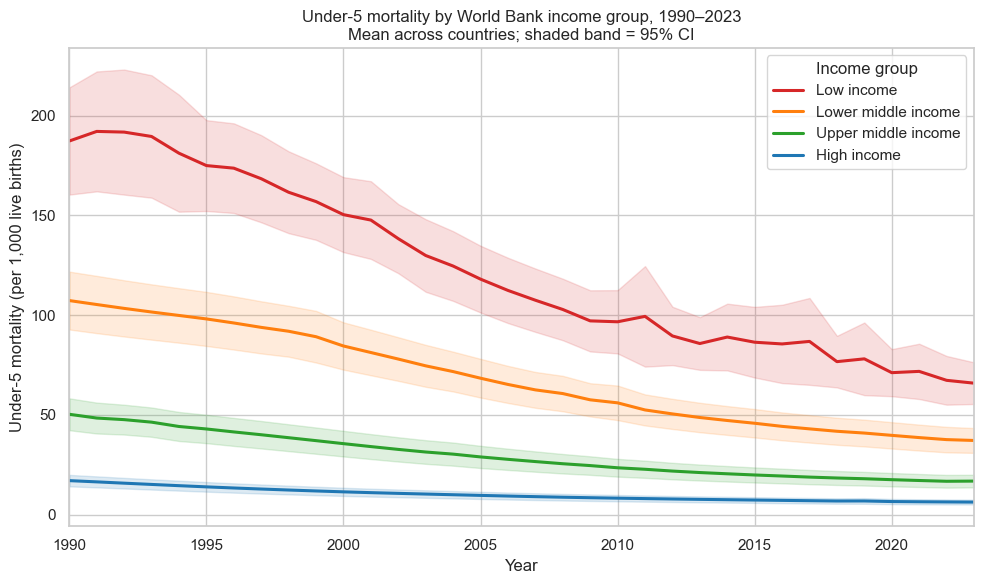

In [36]:
agg = (df_plot.groupby(["income_group", "year"])["u5_mort"]
              .agg(["mean", "std", "count"])
              .reset_index())
agg["ci"] = 1.96 * agg["std"] / agg["count"].pow(0.5)

fig, ax = plt.subplots(figsize=(10, 6))
for grp in INCOME_ORDER:
    sub = agg[agg["income_group"] == grp]
    ax.plot(sub["year"], sub["mean"],
            label=grp, color=INCOME_PALETTE[grp], linewidth=2.2)
    ax.fill_between(sub["year"],
                    sub["mean"] - sub["ci"],
                    sub["mean"] + sub["ci"],
                    color=INCOME_PALETTE[grp], alpha=0.15)

ax.set_xlabel("Year")
ax.set_ylabel("Under-5 mortality (per 1,000 live births)")
ax.set_title("Under-5 mortality by World Bank income group, 1990–2023\n"
             "Mean across countries; shaded band = 95% CI",
             fontsize=12)
ax.legend(title="Income group", loc="upper right")
ax.set_xlim(1990, 2023)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_mort_by_income_timeseries.png", dpi=200)
plt.show()

### Decade averages by income group


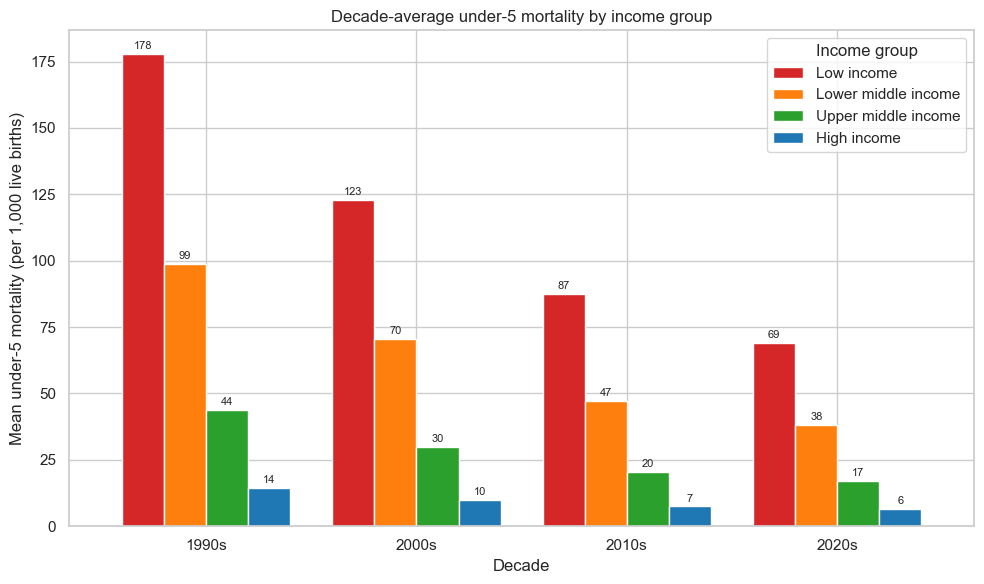

In [37]:
pivot = dec.pivot(index="decade", columns="income_group",
                  values="avg_u5_mort")[INCOME_ORDER]

fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind="bar", ax=ax,
           color=[INCOME_PALETTE[g] for g in INCOME_ORDER],
           edgecolor="white", width=0.8)

ax.set_xlabel("Decade")
ax.set_ylabel("Mean under-5 mortality (per 1,000 live births)")
ax.set_title("Decade-average under-5 mortality by income group")
ax.legend(title="Income group", loc="upper right")
ax.set_xticklabels([f"{int(d)}s" for d in pivot.index], rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=8, padding=2)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_decade_avg_bars.png", dpi=200)
plt.show()